<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-01/trabalho-01/demo_regressaop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

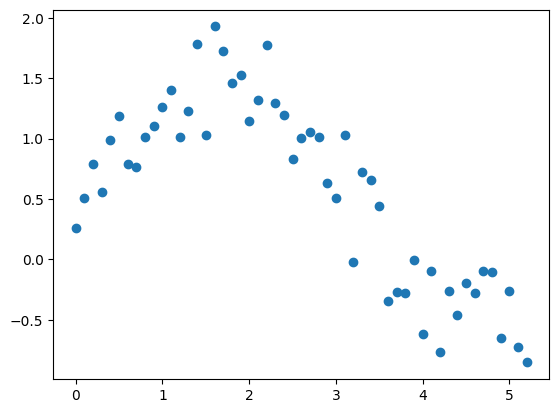

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("data_preg.csv", header=None, names=['x', 'y'])
x = data['x']
y = data['y']

plt.scatter(x, y) # b
plt.show()

In [4]:
from typing import Literal

y_predictions: dict[Literal['p1', 'p2', 'p3', 'p8'], np.ndarray] = {}
y_train_predictions: dict[Literal['p1', 'p2', 'p3', 'p8'], np.ndarray] = {}

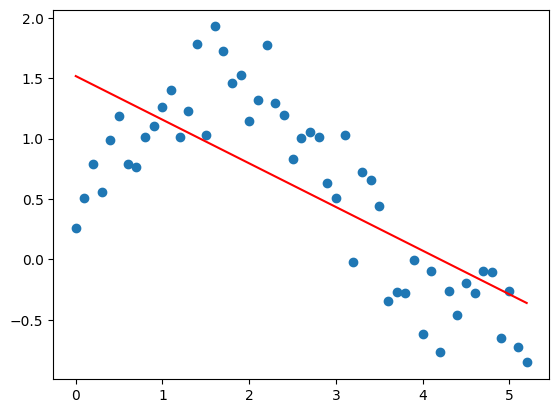

In [5]:
# c)
b1_poly1, b0_poly1 = np.polyfit(x, y, 1)
predict_linear = np.poly1d([b1_poly1, b0_poly1])

y_predictions['p1'] = predict_linear(x)

plt.scatter(x, y)
plt.plot(x, y_predictions['p1'], 'r')
plt.show()

In [6]:
from copy import deepcopy

X = x.to_numpy()
y = y.to_numpy()

def polynomial_regression(X: np.ndarray, y: np.ndarray, deg: int) -> tuple[np.ndarray, np.ndarray]:
    X_poly = np.column_stack([X**i for i in range(deg + 1)])

    transposed_matrix = X_poly.T # X^t
    inverted_matrix = np.linalg.inv(transposed_matrix @ X_poly) # (X^t X)^(-1)
    beta = inverted_matrix @ transposed_matrix @ y # (X^t X)^(-1) * X^t * y

    def predict(X: np.ndarray) -> np.ndarray:
        return X @ beta

    return beta, predict(X_poly) # Retorna β e 𝑦̂

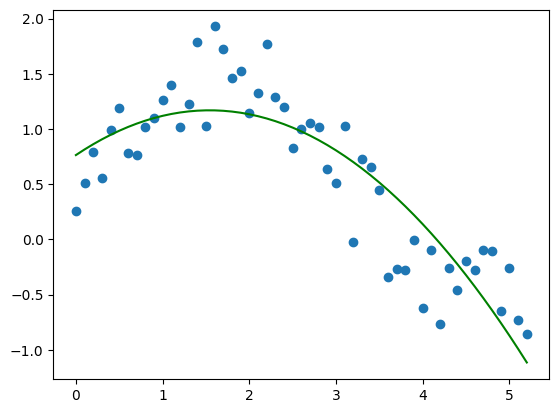

In [7]:
# d)
_, y_predictions['p2'] = polynomial_regression(X, y, 2)

plt.scatter(x, y)
plt.plot(x, y_predictions['p2'], 'g')
plt.show()

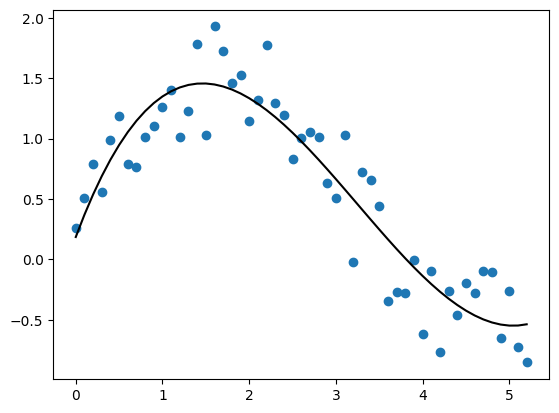

In [8]:
# e)
beta, y_predictions['p3'] = polynomial_regression(X, y, 3)

plt.scatter(x, y)
plt.plot(x, y_predictions['p3'], 'black')
plt.show()

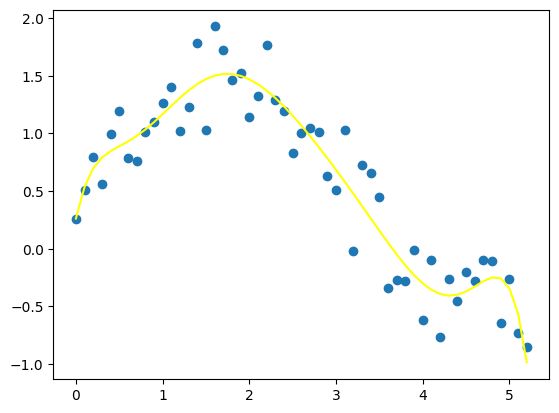

In [9]:
# f)
beta, y_predictions['p8'] = polynomial_regression(X, y, 8)

plt.scatter(x, y)
plt.plot(x, y_predictions['p8'], 'yellow')
plt.show()

In [10]:
def residual(y: float, y_hat: float) -> float:
    return (y - y_hat)**2

def residual_sum(y: np.ndarray, y_hat: np.ndarray) -> float:
    return np.sum([residual(y[i], y_hat[i]) for i in range(len(y))])

def eqm(y: np.ndarray, y_hat: np.ndarray) -> float:
    return 1 / len(y) * residual_sum(y, y_hat)

In [11]:
# g)
for key, value in y_predictions.items():
    print(f'EQM {key}:', eqm(y, value))

EQM p1: 0.2659342636924439
EQM p2: 0.1385264902757942
EQM p3: 0.07869725256060661
EQM p8: 0.05870934697421276


In [12]:
# h)

def split_train_test(x: np.ndarray, y: np.ndarray, proportion: float) -> tuple[np.ndarray, np.ndarray]:
    full_dataset = np.column_stack((x, y))

    # Aleatoriza os dados
    np.random.shuffle(full_dataset)
    train_size = int(len(full_dataset) * proportion)

    return full_dataset[:train_size], full_dataset[train_size:]

# Divide 90/10
training_set, test_set = split_train_test(x, y, 0.9)

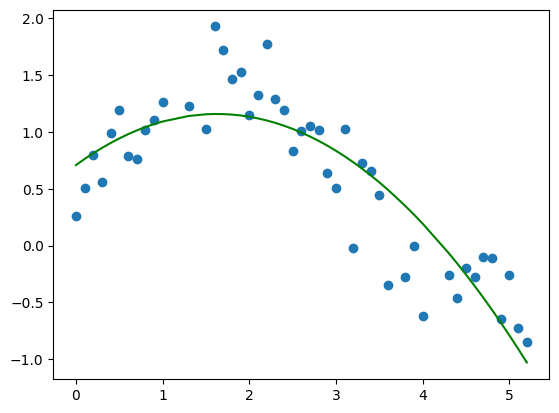

In [17]:
# i)

training_set_x = training_set[:, 0]
training_set_y = training_set[:, 1]

_, y_train_predictions['p2'] = polynomial_regression(training_set_x, training_set_y, 2)

sorted_indexes = np.argsort(training_set_x)

x_sorted = training_set_x[sorted_indexes]
y_sorted = y_train_predictions['p2'][sorted_indexes]

plt.scatter(training_set_x, training_set_y)
plt.plot(x_sorted, y_sorted, 'g')
plt.show()


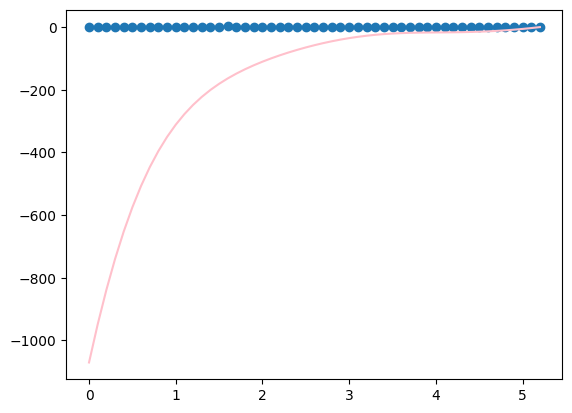

In [14]:
# m)
beta, y_poly20 = polynomial_regression(X, y, 20)

plt.scatter(x, y)
plt.plot(x, y_poly20, 'pink')
plt.show()